In [1]:
import os
import numpy as np 
import pandas as pd
#import cudf # to leverage GPU acceleration
import time  # To measure execution time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import statsmodels.api as sm

In [2]:
print(os.getcwd())    
print()
print(os.listdir("."))

/Users/cagandeliktas/Master-thesis-Nursultan/Preprocessing

['Preprocessing_part_2_treatment_info.ipynb', 'procedureevents_24h.csv', 'radiology.csv.gz', 'vitals_signs_finished.csv', 'Preprocessing.ipynb', 'patients.csv.gz', 'marking_system_finished.csv', 'has_radio_disch_notes.csv', 'diagnoses_icd.csv.gz', 'Preprocessing_part_2_textual_data.ipynb', 'Preprocessing_part_2_comorbidities.ipynb', 'discharge.csv.gz', 'temp_filtered_labevents.csv', 'lab_vars_preliminary.csv', 'pooled_bt_effect.png', 'Preprocessing _part_2_marking_system.ipynb', 'radiology_earliest.csv', 'labevents_filtered.csv', 'inputevents.csv.gz', 'treatment_info_finished.csv', 'labevents_final_summary.csv', 'temp_filtered.csv', 'labevents_summary.csv', 'admissions.csv.gz', 'procedureevents.csv.gz', 'Preprocessing_part_1.ipynb', 'Preprocessing_part_2_labevents.ipynb', 'labevents.csv.gz', 'discharge_detail.csv.gz', '.ipynb_checkpoints', 'chartevents.csv.gz', 'updated_cohort.csv', 'radiology_detail.csv.gz', 'comorbidities_fi

### discharge_detail.csv
This is a companion table providing structured metadata about each discharge note, stored in an Entity-Attribute-Value (EAV) format.
Columns:
* note_id
  * Matches the note_id in discharge.csv.
* subject_id
  * Same as in discharge.csv, included for convenience.
* field_name
  * The type of metadata (e.g., "author" or "location").
* field_value
  * The corresponding value of the field. To preserve privacy, sensitive values (like names) are replaced with "___".
* field_ordinal
  * Indicates the order of the field if multiple entries of the same type exist. For example, if there are multiple authors, they may be numbered 1, 2, etc.

In [3]:
discharge_detail_path = "discharge_detail.csv.gz"
discharge_detail = pd.read_csv(discharge_detail_path)
discharge_detail.head()

,note_id,subject_id,field_name,field_value,field_ordinal
0,10000032-DS-21,10000032,author,___,1
1,10000032-DS-22,10000032,author,___,1
2,10000032-DS-23,10000032,author,___,1
3,10000032-DS-24,10000032,author,___,1
4,10000084-DS-17,10000084,author,___,1


### discharge.csv
This table contains free-text discharge summaries from hospital stays, each representing a single note written at the time of a patient's discharge. These summaries are valuable for understanding the clinical course and outcomes of hospitalization.
Columns:
* note_id
  * Unique identifier for the note. Format: subject_id + "DS" (for discharge) + sequence number (e.g., 10000032-DS-21).
* subject_id
  * Anonymized patient identifier.
* hadm_id
  * Hospital admission ID—useful for linking this note to other hospital-level tables in MIMIC-IV (e.g., diagnoses, labs).
* note_type
  * Type of the note. For this file, it's always "DS" indicating Discharge Summary.
* note_seq
  * The sequence number of the discharge note for the patient (i.e., which number in a series if there are multiple admissions).
* charttime
  * The time the note describes (usually the discharge date/time).
* storetime
  * The time the note was entered into the system (can be after charttime).
* text
  * The full, de-identified discharge summary in free-text form. Fields like name, date of birth, and ID numbers are replaced with placeholders like ___ to ensure privacy.

In [4]:
discharge_path = "discharge.csv.gz"
discharge = pd.read_csv(discharge_path, nrows=100)
discharge.head()

,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,text
0,10000032-DS-21,10000032,22595853,DS,21,2180-05-07 00:00:00,2180-05-09 15:26:00,\nName: ___ Unit No: _...
1,10000032-DS-22,10000032,22841357,DS,22,2180-06-27 00:00:00,2180-07-01 10:15:00,\nName: ___ Unit No: _...
2,10000032-DS-23,10000032,29079034,DS,23,2180-07-25 00:00:00,2180-07-25 21:42:00,\nName: ___ Unit No: _...
3,10000032-DS-24,10000032,25742920,DS,24,2180-08-07 00:00:00,2180-08-10 05:43:00,\nName: ___ Unit No: _...
4,10000084-DS-17,10000084,23052089,DS,17,2160-11-25 00:00:00,2160-11-25 15:09:00,\nName: ___ Unit No: __...


In [5]:
# Compare first two notes' full text
print(discharge.loc[0, "text"][:500])  # First 500 characters
print(discharge.loc[1, "text"][:500])

 
Name:  ___                     Unit No:   ___
 
Admission Date:  ___              Discharge Date:   ___
 
Date of Birth:  ___             Sex:   F
 
Service: MEDICINE
 
Allergies: 
No Known Allergies / Adverse Drug Reactions
 
Attending: ___
 
Chief Complaint:
Worsening ABD distension and pain 
 
Major Surgical or Invasive Procedure:
Paracentesis

 
History of Present Illness:
___ HCV cirrhosis c/b ascites, hiv on ART, h/o IVDU, COPD, 
bioplar, PTSD, presented from OSH ED with worsening abd 
d
 
Name:  ___                     Unit No:   ___
 
Admission Date:  ___              Discharge Date:   ___
 
Date of Birth:  ___             Sex:   F
 
Service: MEDICINE
 
Allergies: 
Percocet
 
Attending: ___.
 
Chief Complaint:
abdominal fullness and discomfort
 
Major Surgical or Invasive Procedure:
___ diagnostic paracentesis
___ therapeutic paracentesis

 
History of Present Illness:
___ with HIV on HAART, COPD, HCV cirrhosis complicated by 
ascites and HE admitted with abdominal distention

In [6]:
# Load admissions
admissions = pd.read_csv("admissions.csv.gz")

# Load discharge notes
discharge = pd.read_csv("discharge.csv.gz") 

# Mark admissions with discharge note
admissions['has_discharge_note'] = admissions['hadm_id'].isin(discharge['hadm_id']).astype(int)

In [7]:
print(admissions['has_discharge_note'].value_counts(normalize=True))

has_discharge_note
1    0.607537
0    0.392463
Name: proportion, dtype: float64


In [8]:
# Load admissions table
#admissions = pd.read_csv("admissions.csv.gz")

# Load radiology notes
radiology = pd.read_csv("radiology.csv.gz")

# Mark which hospital admissions have at least one radiology note
admissions['has_radiology_note'] = admissions['hadm_id'].isin(radiology['hadm_id']).astype(int)

# View proportion
print(admissions['has_radiology_note'].value_counts(normalize=True))

has_radiology_note
1    0.566896
0    0.433104
Name: proportion, dtype: float64


### radiology_detail.csv
This table provides additional metadata for each radiology note in an Entity-Attribute-Value (EAV) format. It includes:

* note_id: Matches the corresponding note in radiology.csv
* subject_id: De-identified patient ID
* field_name: The name of the metadata field (e.g., exam_code, exam_name)
* field_value: The corresponding value (e.g., C11, CHEST (PA & LAT))
* field_ordinal: Sequence number if multiple values exist for the same note and field

In [9]:
radiology_detail_path = "radiology_detail.csv.gz"
radiology_detail = pd.read_csv(radiology_detail_path, nrows=1000)
radiology_detail.head()

,note_id,subject_id,field_name,field_value,field_ordinal
0,10000032-RR-14,10000032,exam_code,C11,1
1,10000032-RR-14,10000032,exam_name,CHEST (PA & LAT),1
2,10000032-RR-15,10000032,exam_code,U314,1
3,10000032-RR-15,10000032,exam_code,U644,3
4,10000032-RR-15,10000032,exam_code,W82,2


### radiology.csv
This file contains free-text radiology reports from a variety of imaging modalities, such as X-rays, ultrasounds, CT scans, and MRIs. Each row represents one clinical note with the following columns:

* note_id: Unique identifier for the radiology note (e.g., 10000032-RR-14)
* subject_id: De-identified patient identifier
* hadm_id: Hospital admission ID (may be missing if not tied to an admission)
* note_type: Type of note (always RR = Radiology Report)
* note_seq: Sequential number of the note for this subject
* charttime: When the note corresponds to clinical events
* storetime: When the note was stored in the system
* text: The full free-text radiology report, usually organized in semi-structured sections like:
  * EXAMINATION – The type of imaging performed
  * INDICATION – The clinical reason for ordering the study
  * TECHNIQUE – How the imaging was performed
  * COMPARISON – Previous studies used for comparison (if any)
  * FINDINGS – Objective observations made from the image
  * IMPRESSION – Radiologist's conclusion/summary (most clinically relevant)

In [10]:
radiology_path = "radiology.csv.gz"
radiology = pd.read_csv(radiology_path)
radiology.head()

,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,text
0,10000032-RR-14,10000032,22595853.0,RR,14,2180-05-06 21:19:00,2180-05-06 23:32:00,EXAMINATION: CHEST (PA AND LAT)\n\nINDICATION...
1,10000032-RR-15,10000032,22595853.0,RR,15,2180-05-06 23:00:00,2180-05-06 23:26:00,EXAMINATION: LIVER OR GALLBLADDER US (SINGLE ...
2,10000032-RR-16,10000032,22595853.0,RR,16,2180-05-07 09:55:00,2180-05-07 11:15:00,"INDICATION: ___ HCV cirrhosis c/b ascites, hi..."
3,10000032-RR-18,10000032,NaN,RR,18,2180-06-03 12:46:00,2180-06-03 14:01:00,EXAMINATION: Ultrasound-guided paracentesis.\...
4,10000032-RR-20,10000032,NaN,RR,20,2180-07-08 13:18:00,2180-07-08 14:15:00,EXAMINATION: Paracentesis\n\nINDICATION: ___...


In [11]:
# Compare first two notes' full text
print(radiology.loc[0, "text"][:500])  # First 500 characters
print(radiology.loc[1, "text"][:500])

EXAMINATION:  CHEST (PA AND LAT)

INDICATION:  ___ with new onset ascites  // eval for infection

TECHNIQUE:  Chest PA and lateral

COMPARISON:  None.

FINDINGS: 

There is no focal consolidation, pleural effusion or pneumothorax.  Bilateral
nodular opacities that most likely represent nipple shadows. The
cardiomediastinal silhouette is normal.  Clips project over the left lung,
potentially within the breast. The imaged upper abdomen is unremarkable.
Chronic deformity of the posterior left sixth
EXAMINATION:  LIVER OR GALLBLADDER US (SINGLE ORGAN)

INDICATION:  ___ year-old female with cirrhosis, jaundice.

TECHNIQUE:  Grey scale and color Doppler ultrasound images of the abdomen were
obtained.

COMPARISON:  None.

FINDINGS: 

LIVER: The liver is coarsened and nodular in echotexture. There is no focal
liver mass. Main portal vein and its major branches are patent with normal
hepatopetal flow.  The main hepatic artery shows normal arterial waveform. 
There is a small amount of ascites.


### Filtering out the discharge dataset based on hadm_id in ca_patients_filtered

In [12]:
# Timer start
start_time = time.time()

# Paths
discharge_path = "discharge.csv.gz"
ca_patients_path = "ca_patients_filtered.csv"
output_path = "discharge_filtered.csv"

# Load benchmark HADM_IDs
ca_patients = pd.read_csv(ca_patients_path, usecols=['hadm_id'])

print(f"✅ Loaded {ca_patients['hadm_id'].nunique()} unique hospital admissions (HADM_IDs).")

# Chunk size
chunk_size = 500_000  # Adjust as needed

# Filter loop
filtered_chunks = []

for chunk in pd.read_csv(discharge_path, chunksize=chunk_size):
    chunk = chunk[chunk["hadm_id"].isin(ca_patients["hadm_id"])]
    filtered_chunks.append(chunk)

# Concatenate all filtered data
discharge_filtered = pd.concat(filtered_chunks, ignore_index=True)

# Optional: drop charttime if you're excluding first 24h
#discharge_filtered = discharge_filtered.drop(columns=["charttime"])

# Save to CSV
discharge_filtered.to_csv(output_path, index=False)

# Timer end
elapsed_time = (time.time() - start_time) / 60
print(f"✅ Saved filtered discharge data with {discharge_filtered.shape[0]} rows to {output_path}")
print(f"⏳ Total time: {elapsed_time:.2f} minutes")

✅ Loaded 2307 unique hospital admissions (HADM_IDs).
✅ Saved filtered discharge data with 1618 rows to discharge_filtered.csv
⏳ Total time: 0.48 minutes


In [13]:
discharge_filtered.head()

,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,text
0,10001884-DS-38,10001884,26184834,DS,38,2131-01-20 00:00:00,2131-01-20 09:41:00,\nName: ___ Unit No: ___\n \nA...
1,10010471-DS-22,10010471,29842315,DS,22,2155-12-07 00:00:00,2155-12-09 10:22:00,\nName: ___ Unit No: ___\n ...
2,10013569-DS-10,10013569,27993048,DS,10,2167-12-25 00:00:00,2167-12-25 16:07:00,\nName: ___ Unit No: ___\n...
3,10024982-DS-20,10024982,25154057,DS,20,2203-10-11 00:00:00,2203-10-12 00:21:00,\nName: ___ Unit No: ___...
4,10026161-DS-7,10026161,24614671,DS,7,2133-11-15 00:00:00,2133-11-18 20:57:00,\nName: ___ Unit No: ___\n ...


### Filtering Radiology Dataset to Earliest Report per Admission
In this step below, we filtered the radiology dataset to retain only the earliest radiology report for each hospital admission (identified by hadm_id). The rationale behind this choice includes:

* Temporal Relevance: Early radiology notes, recorded close to admission time, are more likely to reflect the patient’s initial clinical condition, which is crucial for in-hospital mortality prediction.
* Noise Reduction: Patients often undergo multiple radiology exams during their stay. Later exams typically represent follow-ups or recovery assessments, which can introduce noise or risk of information leakage in predictive models.
* Efficiency: Selecting a single note per admission reduces the volume of textual data, simplifying downstream preprocessing and modeling efforts.

Since radiology notes usually summarize multiple imaging exams within one text, capturing the earliest note per admission provides a comprehensive, timely snapshot of diagnostic imaging. This approach maintains clinical richness while avoiding duplication and the complexity of handling multiple exam codes.

In [14]:
# Start timer
start_time = time.time()

# Paths
radiology_path = "radiology.csv.gz"
ca_patients_path = "ca_patients_filtered.csv"
output_path = "radiology_earliest.csv"

# Load CA patients (for filtering)
ca_patients = pd.read_csv(ca_patients_path, usecols=['hadm_id'])

# Load radiology data in chunks and filter
chunk_size = 500_000
filtered_chunks = []

for chunk in pd.read_csv(radiology_path, chunksize=chunk_size):
    # Convert 'charttime' to datetime in pandas first
    chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors='coerce')
    # Drop rows with invalid datetimes
    chunk = chunk.dropna(subset=["charttime"])    
    # Filter only relevant hadm_ids
    chunk = chunk[chunk["hadm_id"].isin(ca_patients["hadm_id"])]
    
    filtered_chunks.append(chunk)

# Combine all filtered chunks
radiology_filtered = pd.concat(filtered_chunks, ignore_index=True)

# Sort by hadm_id and charttime to get the earliest
radiology_sorted = radiology_filtered.sort_values(by=["hadm_id", "charttime"])

# Drop duplicates, keeping the first (earliest)
radiology_earliest = radiology_sorted.drop_duplicates(subset=["hadm_id"], keep="first")

# Save
radiology_earliest.to_csv(output_path, index=False)

# Report
elapsed_time = (time.time() - start_time) / 60
print(f"✅ Saved earliest radiology note per patient: {radiology_earliest.shape[0]} rows")
print(f"⏳ Elapsed time: {elapsed_time:.2f} minutes")

✅ Saved earliest radiology note per patient: 1639 rows
⏳ Elapsed time: 0.38 minutes


In [15]:
radiology_earliest.head()

,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,text
6381,13159282-RR-15,13159282,20010074.0,RR,15,2159-04-30 12:39:00,2159-05-02 10:12:00,INDICATION: ___ year old man with HBV and HIV...
8463,14104652-RR-56,14104652,20011505.0,RR,56,2158-05-19 16:44:00,2158-05-19 18:09:00,EXAMINATION: CHEST (PORTABLE AP)\n\nINDICATIO...
5246,12638705-RR-17,12638705,20013945.0,RR,17,2160-11-11 10:18:00,2160-11-11 11:23:00,INDICATION: ___ woman with dual-chamber pacem...
16154,17844820-RR-32,17844820,20014219.0,RR,32,2142-10-07 07:25:00,2142-10-07 08:51:00,EXAMINATION: CHEST (PORTABLE AP)\n\nINDICATIO...
19063,19210871-RR-28,19210871,20020562.0,RR,28,2150-08-06 17:02:00,2150-08-06 17:55:00,EXAMINATION: CHEST (PA AND LAT)\n\nINDICATION...


In [16]:
radiology_earliest.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1639 entries, 6381 to 18942
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   note_id     1639 non-null   object        
 1   subject_id  1639 non-null   int64         
 2   hadm_id     1639 non-null   float64       
 3   note_type   1639 non-null   object        
 4   note_seq    1639 non-null   int64         
 5   charttime   1639 non-null   datetime64[ns]
 6   storetime   1639 non-null   object        
 7   text        1639 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 115.2+ KB


In [17]:
discharge_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1618 entries, 0 to 1617
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   note_id     1618 non-null   object
 1   subject_id  1618 non-null   int64 
 2   hadm_id     1618 non-null   int64 
 3   note_type   1618 non-null   object
 4   note_seq    1618 non-null   int64 
 5   charttime   1618 non-null   object
 6   storetime   1618 non-null   object
 7   text        1618 non-null   object
dtypes: int64(3), object(5)
memory usage: 101.3+ KB


In [18]:
# Load benchmark cohort
ca_patients = pd.read_csv("ca_patients_filtered.csv")

# Load filtered discharge and radiology data (already filtered to hadm_ids in ca_patients)
discharge_filtered = pd.read_csv("discharge_filtered.csv")
radiology_earliest = pd.read_csv("radiology_earliest.csv")

# Add flags
ca_patients["has_discharge_note"] = ca_patients["hadm_id"].isin(discharge_filtered["hadm_id"]).astype(int)
ca_patients["has_radiology_note"] = ca_patients["hadm_id"].isin(radiology_earliest["hadm_id"]).astype(int)

# Check proportion
print(ca_patients[["has_discharge_note", "has_radiology_note"]].mean())


has_discharge_note    0.701344
has_radiology_note    0.710446
dtype: float64


In [19]:
ca_patients.head()

,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,anchor_year_group,dischtime,deathtime,dod,survival_status,has_discharge_note,has_radiology_note
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,2008 - 2010,2131-01-20 05:15:00,2131-01-20 05:15:00,2131-01-20 05:15:00,1,1,1
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,2020 - 2022,2150-12-06 14:22:00,2150-12-06 14:22:00,2150-12-06 14:22:00,1,0,0
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153,F,89,2155,2014 - 2016,2155-12-07 15:30:00,2155-12-07 15:30:00,2155-12-07 15:30:00,1,1,1
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282,F,54,2165,2008 - 2010,2167-12-25 14:53:00,NaN,NaN,0,1,1
4,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387,M,88,2125,2020 - 2022,2125-03-24 16:43:00,2125-03-24 16:43:00,2125-03-24 16:43:00,1,0,0


In [20]:
ca_patients.groupby("survival_status")[["has_discharge_note", "has_radiology_note"]].mean()

,has_discharge_note,has_radiology_note
survival_status,,
0,0.740909,0.746364
1,0.665286,0.677713


* Patients who survived (0) were more likely to have both types of notes recorded compared to those who died (1) in the hospital.
* This could imply better documentation for patients who survived—or perhaps shorter and more acute hospital stays for those who died, resulting in fewer notes.

In [21]:
has_radio_disch_path = "has_radio_disch_notes.csv"
ca_patients.to_csv(has_radio_disch_path, index=False)

In [22]:
# ---------------------------------------------
# 🧪 1. Imports
# ---------------------------------------------
import re
import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# Ensure GPU is available if using BioBERT
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [23]:
# ---------------------------------------------
# 🧼 2. Text Cleaning for TF-IDF
# ---------------------------------------------

# Function for simple cleaning: lowercasing, punctuation & digit removal
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

# Apply cleaning for TF-IDF pipeline
discharge_filtered['text_clean'] = discharge_filtered['text'].apply(clean_text)
radiology_earliest['text_clean'] = radiology_earliest['text'].apply(clean_text)

# Keep raw text for BERT pipeline
discharge_filtered['text_raw'] = discharge_filtered['text']
radiology_earliest['text_raw'] = radiology_earliest['text']

In this work, unlike the approach used in “TF-IDF vs Word Embeddings for Morbidity Identification in Clinical Notes: An Initial Study” by Dessi et al., we did not set max_features based on the length of the longest preprocessed text (in characters).

Instead, we used a fixed value of max_features=500 for the TF-IDF vectorizer to control vocabulary size. This choice was guided by practical considerations and supported by related literature, such as the study “Ensembling Classical Machine Learning and Deep Learning Approaches for Morbidity Identification From Clinical Notes” by Kumar et al., where they used max_features=600.

Using a fixed max_features ensures a consistent vocabulary size across datasets and avoids the arbitrary scaling issues that can arise from using character-length-based values. It also aligns better with the TF-IDF vectorizer’s intended role of selecting a fixed number of important unique tokens (words) rather than being related to document length.

In [24]:
# ---------------------------------------------
# 📊 3. TF-IDF Feature Extraction
# ---------------------------------------------

# Use separate vectorizers to avoid vocabulary clashes
tfidf_discharge = TfidfVectorizer(max_features=500, stop_words='english')
tfidf_radiology = TfidfVectorizer(max_features=500, stop_words='english')

# Fit and transform
X_discharge_tfidf = tfidf_discharge.fit_transform(discharge_filtered['text_clean'])
X_radiology_tfidf = tfidf_radiology.fit_transform(radiology_earliest['text_clean'])

# Convert to DataFrame for inspection and merge
df_discharge_tfidf = pd.DataFrame(X_discharge_tfidf.toarray(), columns=[f"disch_tfidf_{f}" for f in tfidf_discharge.get_feature_names_out()])
df_radiology_tfidf = pd.DataFrame(X_radiology_tfidf.toarray(), columns=[f"radio_tfidf_{f}" for f in tfidf_radiology.get_feature_names_out()])

# Add hadm_id for joining later
df_discharge_tfidf['hadm_id'] = discharge_filtered['hadm_id'].values
df_radiology_tfidf['hadm_id'] = radiology_earliest['hadm_id'].values

In [25]:
df_discharge_tfidf.head()

,disch_tfidf____,disch_tfidf_abd,disch_tfidf_abdomen,disch_tfidf_abdominal,disch_tfidf_able,disch_tfidf_abnormal,disch_tfidf_activity,disch_tfidf_acute,disch_tfidf_admission,disch_tfidf_admitted,...,disch_tfidf_weaned,disch_tfidf_week,disch_tfidf_weeks,disch_tfidf_weight,disch_tfidf_went,disch_tfidf_worsening,disch_tfidf_wound,disch_tfidf_xs,disch_tfidf_year,hadm_id
0,0.588734,0.000000,0.018947,0.000000,0.028144,0.000000,0.000000,0.052329,0.056070,0.019692,...,0.028651,0.000000,0.0,0.031385,0.028263,0.000000,0.000000,0.024129,0.000000,26184834
1,0.613552,0.000000,0.014056,0.000000,0.000000,0.000000,0.000000,0.012940,0.062395,0.000000,...,0.000000,0.000000,0.0,0.000000,0.020967,0.020584,0.000000,0.000000,0.000000,29842315
2,0.726372,0.016380,0.006294,0.000000,0.000000,0.000000,0.007597,0.028970,0.055875,0.000000,...,0.066619,0.020143,0.0,0.031275,0.000000,0.036866,0.013083,0.000000,0.000000,27993048
3,0.738764,0.000000,0.008118,0.011216,0.012059,0.041741,0.000000,0.059791,0.024025,0.016876,...,0.024553,0.000000,0.0,0.000000,0.024220,0.011889,0.000000,0.000000,0.022773,25154057
4,0.602514,0.019625,0.015081,0.000000,0.000000,0.000000,0.000000,0.000000,0.078104,0.000000,...,0.068416,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24614671


In [26]:
df_radiology_tfidf.head()

,radio_tfidf____,radio_tfidf_abdomen,radio_tfidf_abdominal,radio_tfidf_abnormalities,radio_tfidf_abnormality,radio_tfidf_acquired,radio_tfidf_acquisition,radio_tfidf_acute,radio_tfidf_additional,radio_tfidf_adjacent,...,radio_tfidf_volumes,radio_tfidf_wall,radio_tfidf_white,radio_tfidf_widening,radio_tfidf_wire,radio_tfidf_wires,radio_tfidf_woman,radio_tfidf_xray,radio_tfidf_year,hadm_id
0,0.150142,0.033425,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.264551,0.000000,0.000000,0.0,0.026781,20010074.0
1,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,20011505.0
2,0.064173,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.177316,0.0,0.000000,20013945.0
3,0.130729,0.000000,0.0,0.0,0.000000,0.0,0.0,0.250841,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.209958,0.000000,0.0,0.151566,20014219.0
4,0.132012,0.000000,0.0,0.0,0.096797,0.0,0.0,0.063326,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,20020562.0


### Choosing optimal cutoff: Target Variance–based SVD
The code below reduces high-dimensional TF-IDF vectors using TruncatedSVD, keeping only the components that explain at least 80% of the total variance.

What it does:
 * Finds the optimal number of components to capture 80% variance.
 * Applies SVD to reduce feature size (e.g., from 500 to ~100–150).
 * Plots how variance accumulates with more components.

Why it's useful:
 * Shrinks sparse TF-IDF data → faster, less overfitting.
 * Keeps essential semantic signals.
 * Makes text features more manageable and model-friendly.

In [27]:
from sklearn.decomposition import TruncatedSVD

def reduce_tfidf(df_tfidf, name_prefix="tfidf", target_variance=0.80):
    hadm_ids = df_tfidf['hadm_id'].values
    X = df_tfidf.drop(columns='hadm_id').values

    # Fit full SVD to check explained variance
    svd_full = TruncatedSVD(n_components=min(X.shape[1]-1, 300), random_state=42)
    X_svd_full = svd_full.fit_transform(X)
    cumulative_variance = np.cumsum(svd_full.explained_variance_ratio_)

    # Find optimal number of components to keep target variance
    optimal_n = np.argmax(cumulative_variance >= target_variance) + 1
    print(f"🔍 {name_prefix}: Optimal components for {target_variance*100:.0f}% variance = {optimal_n}")

    # Refit using optimal number
    svd = TruncatedSVD(n_components=optimal_n, random_state=42)
    X_reduced = svd.fit_transform(X)

    # Plot cumulative variance
    plt.figure(figsize=(8, 4))
    plt.plot(cumulative_variance, marker='o')
    plt.axhline(target_variance, color='r', linestyle='--', label=f'Target Variance {target_variance*100:.0f}%')
    plt.axvline(optimal_n, color='g', linestyle='--', label=f'{optimal_n} Components')
    plt.title(f'Cumulative Variance for {name_prefix}')
    plt.xlabel('Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.legend()
    plt.show()

    # Wrap in DataFrame
    df_reduced = pd.DataFrame(X_reduced, columns=[f"{name_prefix}_svd_{i}" for i in range(optimal_n)])
    df_reduced["hadm_id"] = hadm_ids
    return df_reduced, svd, optimal_n

🔍 disch_tfidf: Optimal components for 80% variance = 136


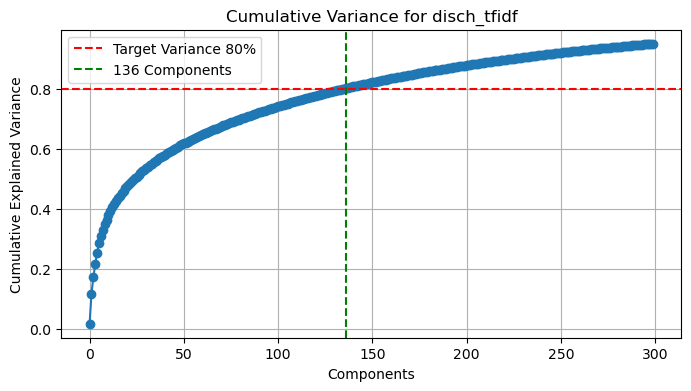

🔍 radio_tfidf: Optimal components for 80% variance = 198


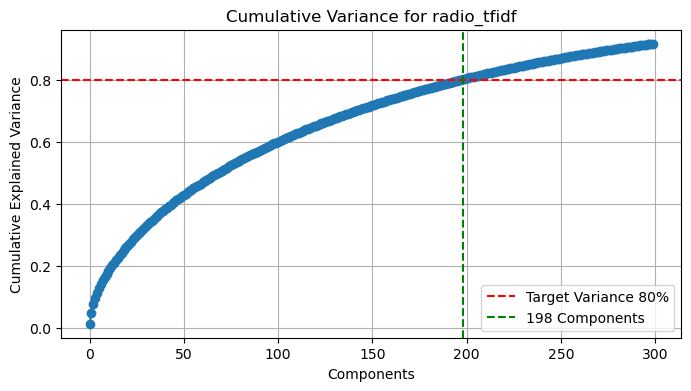

In [28]:
df_discharge_tfidf_svd, svd_disch, n_disch_tfidf = reduce_tfidf(df_discharge_tfidf, name_prefix="disch_tfidf")
df_radiology_tfidf_svd, svd_radio, n_radio_tfidf = reduce_tfidf(df_radiology_tfidf, name_prefix="radio_tfidf")

In [29]:
df_discharge_tfidf_svd.head()

,disch_tfidf_svd_0,disch_tfidf_svd_1,disch_tfidf_svd_2,disch_tfidf_svd_3,disch_tfidf_svd_4,disch_tfidf_svd_5,disch_tfidf_svd_6,disch_tfidf_svd_7,disch_tfidf_svd_8,disch_tfidf_svd_9,...,disch_tfidf_svd_127,disch_tfidf_svd_128,disch_tfidf_svd_129,disch_tfidf_svd_130,disch_tfidf_svd_131,disch_tfidf_svd_132,disch_tfidf_svd_133,disch_tfidf_svd_134,disch_tfidf_svd_135,hadm_id
0,0.820109,0.029019,0.043053,0.292052,-0.009378,-0.007280,0.082465,-0.090557,-0.088351,-0.103409,...,-0.001307,0.044238,0.002943,0.000982,-0.025030,0.038354,-0.042276,0.016909,0.003371,26184834
1,0.813491,-0.018730,-0.176217,-0.017713,0.038228,-0.087261,0.025608,-0.132345,0.039766,0.123576,...,0.003504,0.014866,0.030032,0.051963,0.008475,-0.023328,-0.025387,-0.008719,0.030539,29842315
2,0.867502,0.068534,0.061092,0.178272,-0.020280,0.150148,-0.033889,0.057089,0.144349,0.054790,...,0.005003,-0.001640,-0.002814,0.003160,0.006276,0.010349,0.025343,-0.044990,0.027241,27993048
3,0.875944,-0.068331,-0.072424,-0.119846,-0.097669,0.154884,0.010451,0.026041,0.113147,0.017317,...,0.022341,0.018735,0.002077,0.021433,-0.034671,-0.023991,-0.014706,0.022562,-0.013460,25154057
4,0.755563,-0.021121,-0.195928,-0.120034,0.086599,-0.102282,-0.116882,-0.098443,0.085144,0.128551,...,0.022242,0.042014,-0.017934,0.045657,-0.038212,0.021603,0.002335,-0.021694,0.004095,24614671


In [30]:
df_radiology_tfidf_svd.head()

,radio_tfidf_svd_0,radio_tfidf_svd_1,radio_tfidf_svd_2,radio_tfidf_svd_3,radio_tfidf_svd_4,radio_tfidf_svd_5,radio_tfidf_svd_6,radio_tfidf_svd_7,radio_tfidf_svd_8,radio_tfidf_svd_9,...,radio_tfidf_svd_189,radio_tfidf_svd_190,radio_tfidf_svd_191,radio_tfidf_svd_192,radio_tfidf_svd_193,radio_tfidf_svd_194,radio_tfidf_svd_195,radio_tfidf_svd_196,radio_tfidf_svd_197,hadm_id
0,0.166938,-0.056673,0.094061,0.152188,0.137337,-0.130276,-0.033080,0.033803,0.144110,0.026393,...,-0.005645,-0.019758,-0.040072,0.021196,0.099003,0.031132,-0.025337,-0.068247,-0.051497,20010074.0
1,0.441498,0.090733,-0.022464,-0.070618,-0.052585,0.143722,-0.062075,-0.012372,-0.020196,-0.024086,...,0.022124,0.056234,-0.025961,0.000842,-0.030926,0.053895,0.022186,0.008543,-0.039671,20011505.0
2,0.247952,-0.062609,-0.074490,-0.003672,-0.030639,-0.161493,0.101366,-0.074162,0.073540,0.056893,...,0.001290,-0.004948,-0.011562,0.049949,0.012793,-0.021590,0.041023,-0.035903,-0.033646,20013945.0
3,0.294236,-0.156961,-0.192279,-0.153571,0.086398,-0.210120,0.101567,0.104846,-0.048459,0.015791,...,-0.023618,-0.002059,-0.034910,0.011903,-0.027575,-0.030508,0.068786,0.015472,-0.036520,20014219.0
4,0.391751,-0.132536,-0.152036,0.029048,0.010189,-0.043418,0.055466,-0.022133,-0.039047,0.072138,...,0.023898,-0.021134,-0.040881,0.008039,-0.007289,0.044561,-0.012780,-0.012359,0.052384,20020562.0


In [33]:
# ---------------------------------------------
# 🧠 4. BioBERT Embedding Extraction
# ---------------------------------------------

# Load BioBERT tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.1")
model = AutoModel.from_pretrained("dmis-lab/biobert-base-cased-v1.1").to(device)
model.eval()

# Function to compute mean pooled BioBERT embedding
def get_bert_embedding(texts, tokenizer, model, max_length=512):
    embeddings = []

    for text in tqdm(texts):
        encoded = tokenizer(text, truncation=True, padding='max_length', max_length=max_length,
                            return_tensors='pt')
        input_ids = encoded['input_ids'].to(device)
        attention_mask = encoded['attention_mask'].to(device)

        with torch.no_grad():
            output = model(input_ids=input_ids, attention_mask=attention_mask)
        
        # Use mean of last hidden state
        last_hidden_state = output.last_hidden_state.squeeze(0)
        mask = attention_mask.squeeze(0).unsqueeze(-1).expand(last_hidden_state.size()).float()
        masked_embeddings = last_hidden_state * mask
        mean_embedding = masked_embeddings.sum(0) / mask.sum(0)
        
        embeddings.append(mean_embedding.cpu().numpy())

    return np.array(embeddings)

/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [34]:
# Get BioBERT embeddings (discharge)
disch_bert_embed = get_bert_embedding(discharge_filtered['text_raw'].tolist(), tokenizer, model)

# Convert to DataFrame
df_discharge_bert = pd.DataFrame(disch_bert_embed, columns=[f'disch_bert_{i}' for i in range(disch_bert_embed.shape[1])])
df_discharge_bert['hadm_id'] = discharge_filtered['hadm_id'].values

# Get BioBERT embeddings (radiology)
radio_bert_embed = get_bert_embedding(radiology_earliest['text_raw'].tolist(), tokenizer, model)

# Convert to DataFrame
df_radiology_bert = pd.DataFrame(radio_bert_embed, columns=[f'radio_bert_{i}' for i in range(radio_bert_embed.shape[1])])
df_radiology_bert['hadm_id'] = radiology_earliest['hadm_id'].values

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1639/1639 [07:05<00:00,  3.86it/s]


In [37]:
df_discharge_bert.head()

,disch_bert_0,disch_bert_1,disch_bert_2,disch_bert_3,disch_bert_4,disch_bert_5,disch_bert_6,disch_bert_7,disch_bert_8,disch_bert_9,...,disch_bert_759,disch_bert_760,disch_bert_761,disch_bert_762,disch_bert_763,disch_bert_764,disch_bert_765,disch_bert_766,disch_bert_767,hadm_id
0,0.108160,-0.182751,0.007719,0.064064,-0.023285,-0.124173,-0.238207,0.079495,0.028980,0.173596,...,0.031628,-0.017787,-0.284040,-0.096543,-0.203780,-0.137811,0.130912,0.084308,0.349442,26184834
1,0.165449,-0.216158,0.144828,0.024731,0.126147,-0.208603,-0.392925,0.108373,-0.063085,0.121089,...,0.165075,-0.072130,-0.338609,-0.144957,-0.147293,-0.048871,0.120400,-0.036033,0.363360,29842315
2,0.087813,-0.178463,0.114058,0.084518,0.006973,-0.210240,-0.319883,0.090743,-0.144173,0.238654,...,0.155943,-0.017788,-0.341146,-0.042594,-0.075759,-0.056292,0.091949,-0.014989,0.409080,27993048
3,0.206576,-0.093738,0.113751,0.085251,0.103036,-0.143916,-0.266468,0.078120,-0.115151,0.212842,...,0.141177,-0.005098,-0.301869,-0.125434,-0.161043,-0.033830,0.160375,0.012673,0.380122,25154057
4,0.145096,-0.167560,0.084712,-0.006661,-0.019226,-0.183334,-0.300722,0.103536,-0.075977,0.068831,...,0.235688,-0.086494,-0.318680,-0.109372,-0.164947,-0.019507,0.164206,-0.026750,0.361418,24614671


In [38]:
df_radiology_bert.head()

,radio_bert_0,radio_bert_1,radio_bert_2,radio_bert_3,radio_bert_4,radio_bert_5,radio_bert_6,radio_bert_7,radio_bert_8,radio_bert_9,...,radio_bert_759,radio_bert_760,radio_bert_761,radio_bert_762,radio_bert_763,radio_bert_764,radio_bert_765,radio_bert_766,radio_bert_767,hadm_id
0,0.207962,-0.189307,0.103958,0.176867,-0.007055,-0.060088,-0.335464,0.120467,-0.084790,0.236700,...,0.126402,-0.070302,-0.225282,-0.154365,-0.319226,0.141123,0.335819,0.069063,0.339545,20010074.0
1,0.209354,-0.171571,0.169434,0.129968,0.295644,-0.045431,-0.139172,0.128290,-0.102105,0.282123,...,0.011603,0.088014,-0.108155,-0.000793,-0.229654,-0.069818,0.207923,0.100664,0.128073,20011505.0
2,0.254341,-0.141473,0.210734,0.044087,0.208106,0.086963,-0.254942,0.184722,-0.172880,-0.037113,...,0.111610,-0.001105,-0.045022,-0.070602,-0.163826,0.084651,0.222363,0.110171,0.207674,20013945.0
3,-0.016040,-0.166140,0.154088,0.112008,0.211415,-0.096317,-0.068406,0.051223,-0.111571,0.122778,...,0.070342,-0.128816,-0.150606,0.030789,-0.181838,-0.140201,0.256818,0.027496,0.004046,20014219.0
4,0.228286,-0.214237,0.159197,0.057379,0.163430,-0.087198,-0.147073,0.142871,-0.097907,0.175689,...,-0.016217,0.064442,-0.083487,-0.139880,-0.160743,-0.038790,0.273881,0.049643,0.141379,20020562.0


### Choosing optimal cutoff: Target Variance–based PCA
The code below reduces the 768-dimensional BioBERT embeddings using PCA, keeping only the components that explain at least 80% of the total variance.

What it does:
 * Finds the optimal number of components needed to capture 80% variance.
 * Applies PCA to reduce the embedding size (e.g., from 768 to ~20–50).
 * Plots how variance builds up as components increase.

Why it's useful:
 * Fewer features → faster and simpler models.
 * Minimal information loss → good performance.
 * Helps balance interpretability and efficiency in your final dataset.

In [39]:
from sklearn.decomposition import PCA

def reduce_bert_embeddings_auto(df_bert, name_prefix="bert", target_variance=0.80):
    hadm_ids = df_bert['hadm_id'].values
    embeddings = df_bert.drop(columns='hadm_id').values

    # First fit PCA with all components to find how many are needed
    pca_full = PCA(n_components=min(embeddings.shape[0], embeddings.shape[1]), random_state=42)
    pca_full.fit(embeddings)

    # Compute cumulative explained variance
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
    
    # Find the number of components that reach the target variance
    n_components_optimal = np.argmax(cumulative_variance >= target_variance) + 1
    print(f"🔍 Optimal number of components to reach {target_variance*100:.1f}% variance: {n_components_optimal}")

    # Fit PCA again using optimal number of components
    pca = PCA(n_components=n_components_optimal, random_state=42)
    reduced = pca.fit_transform(embeddings)

    # Plot cumulative variance
    plt.figure(figsize=(8, 4))
    plt.plot(cumulative_variance, marker='o')
    plt.axhline(target_variance, color='r', linestyle='--', label=f'{target_variance*100:.0f}% Target Variance')
    plt.axvline(n_components_optimal, color='g', linestyle='--', label=f'{n_components_optimal} Components')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title(f'Cumulative Variance for {name_prefix}')
    plt.grid(True)
    plt.legend()
    plt.show()

    # Create reduced DataFrame
    df_reduced = pd.DataFrame(reduced, columns=[f"{name_prefix}_pca_{i}" for i in range(n_components_optimal)])
    df_reduced["hadm_id"] = hadm_ids

    return df_reduced, pca, n_components_optimal


🔍 Optimal number of components to reach 90.0% variance: 113


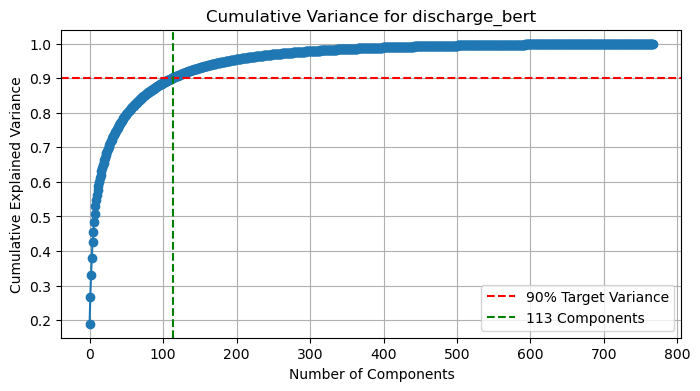

🔍 Optimal number of components to reach 90.0% variance: 115


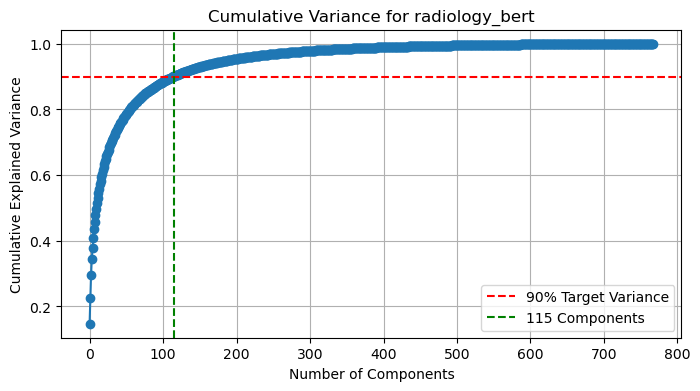

In [40]:
df_discharge_bert_pca, pca_discharge, n_disch = reduce_bert_embeddings_auto(df_discharge_bert, name_prefix="discharge_bert", target_variance=0.90)
df_radiology_bert_pca, pca_radiology, n_radio = reduce_bert_embeddings_auto(df_radiology_bert, name_prefix="radiology_bert", target_variance=0.90)

In [41]:
df_discharge_bert_pca.head()

,discharge_bert_pca_0,discharge_bert_pca_1,discharge_bert_pca_2,discharge_bert_pca_3,discharge_bert_pca_4,discharge_bert_pca_5,discharge_bert_pca_6,discharge_bert_pca_7,discharge_bert_pca_8,discharge_bert_pca_9,...,discharge_bert_pca_104,discharge_bert_pca_105,discharge_bert_pca_106,discharge_bert_pca_107,discharge_bert_pca_108,discharge_bert_pca_109,discharge_bert_pca_110,discharge_bert_pca_111,discharge_bert_pca_112,hadm_id
0,-0.179291,0.229837,-0.416943,-0.281511,-0.006218,-0.082924,-0.385932,0.194954,-0.161924,0.146088,...,0.041775,0.082041,-0.084919,-0.018088,-0.028835,-0.031302,-0.072184,0.050644,0.037684,26184834
1,-0.594164,-0.289803,0.153041,0.325077,-0.342357,-0.440808,0.281053,-0.142319,-0.352552,0.031051,...,-0.067707,-0.053374,-0.021202,0.045407,0.018577,0.097257,0.026675,-0.064947,-0.049412,29842315
2,0.216702,0.014752,0.430462,-0.236666,-0.091045,-0.637474,0.017073,0.179336,0.047562,-0.160557,...,0.125884,-0.058302,0.034722,-0.036158,0.007474,-0.007017,-0.016404,-0.038612,0.016060,27993048
3,-0.675837,0.002136,0.065202,-0.513063,0.231875,-0.774476,0.453415,-0.148107,-0.031382,0.224685,...,0.056299,0.059447,-0.133605,-0.065072,0.004149,0.071709,0.012301,-0.052609,0.064951,25154057
4,-0.222590,0.233064,0.389523,0.574029,-0.005891,-0.028487,-0.208915,-0.351571,-0.014719,-0.058696,...,0.042490,-0.004375,0.040466,-0.026755,-0.006384,0.106880,-0.076831,0.085613,-0.022906,24614671


In [42]:
df_radiology_bert_pca.head()

,radiology_bert_pca_0,radiology_bert_pca_1,radiology_bert_pca_2,radiology_bert_pca_3,radiology_bert_pca_4,radiology_bert_pca_5,radiology_bert_pca_6,radiology_bert_pca_7,radiology_bert_pca_8,radiology_bert_pca_9,...,radiology_bert_pca_106,radiology_bert_pca_107,radiology_bert_pca_108,radiology_bert_pca_109,radiology_bert_pca_110,radiology_bert_pca_111,radiology_bert_pca_112,radiology_bert_pca_113,radiology_bert_pca_114,hadm_id
0,1.008452,1.502374,-0.136041,-0.346962,-0.043336,0.356639,0.249013,-0.138622,0.170885,-0.010770,...,-0.019655,-0.019158,0.025380,0.098119,0.095462,-0.031449,-0.017597,0.008578,-0.088363,20010074.0
1,-0.360545,-0.964813,-0.307610,0.022035,-0.342646,-0.179094,-0.557419,-0.092006,-0.435418,-0.515296,...,0.088783,0.059092,-0.034959,0.058205,0.011318,-0.025342,0.015276,0.014717,0.163569,20011505.0
2,-0.969309,-0.415881,-0.137091,-0.330754,0.406269,0.311183,-0.038294,-0.037833,0.384216,0.083898,...,0.007800,0.036002,0.070649,0.172828,0.083436,0.043101,0.147445,-0.043804,-0.095709,20013945.0
3,-1.257252,0.334005,0.959949,0.087599,0.654281,0.063370,0.145579,0.526437,-0.021850,0.024635,...,0.008002,0.101434,0.072777,0.130036,-0.179603,0.175712,-0.072333,0.053464,-0.059691,20014219.0
4,0.064182,0.024946,0.315659,0.150057,-0.856670,0.028612,-0.288930,-0.323427,-0.255026,0.270989,...,0.008257,-0.010250,0.085204,-0.081060,0.006150,-0.103314,0.080244,0.023477,0.018313,20020562.0


### 🔍 Why PCA for BERT and TruncatedSVD for TF-IDF?
✅ BERT → PCA
 * BERT embeddings are dense, continuous vectors (768-dim), not sparse.
 * PCA is well-suited for dense numerical data, as it finds directions of maximum variance in continuous space.
 * PCA benefits from centering the data (mean subtraction), which aligns well with BERT’s distributional properties.

✅ TF-IDF → TruncatedSVD
 * TF-IDF matrices are typically very high-dimensional and sparse.
 * Standard PCA is inefficient on sparse matrices (requires dense input and lots of memory).
 * TruncatedSVD (aka Latent Semantic Analysis) is PCA-like but optimized for sparse, non-centered matrices — ideal for TF-IDF.

In [43]:
# Load only the hadm_id column (drop all others)
ca_patients = pd.read_csv('ca_patients_filtered.csv', usecols=['hadm_id'])

# Ensure hadm_id is integer (match merge format)
ca_patients['hadm_id'] = ca_patients['hadm_id'].astype(int)

print(f"✅ Loaded {len(ca_patients)} ICU stays with only hadm_id")


✅ Loaded 2307 ICU stays with only hadm_id


In [44]:
# ---------------------------------------------
# 🔗 5. Merge with ca_patients using hadm_id
# ---------------------------------------------

# Start from original dataset
final_df = ca_patients.copy()

# Ensure correct dtype for merging
for df in [df_discharge_tfidf_svd, df_radiology_tfidf_svd, df_discharge_bert_pca, df_radiology_bert_pca]:
    df['hadm_id'] = df['hadm_id'].astype(int)

# Merge all features
final_df = final_df.merge(df_discharge_tfidf_svd, on='hadm_id', how='left')
final_df = final_df.merge(df_radiology_tfidf_svd, on='hadm_id', how='left')
final_df = final_df.merge(df_discharge_bert_pca, on='hadm_id', how='left')
final_df = final_df.merge(df_radiology_bert_pca, on='hadm_id', how='left')

print(f"✅ Final shape after merging: {final_df.shape}")
final_df.head()

✅ Final shape after merging: (2307, 563)


,hadm_id,disch_tfidf_svd_0,disch_tfidf_svd_1,disch_tfidf_svd_2,disch_tfidf_svd_3,disch_tfidf_svd_4,disch_tfidf_svd_5,disch_tfidf_svd_6,disch_tfidf_svd_7,disch_tfidf_svd_8,...,radiology_bert_pca_105,radiology_bert_pca_106,radiology_bert_pca_107,radiology_bert_pca_108,radiology_bert_pca_109,radiology_bert_pca_110,radiology_bert_pca_111,radiology_bert_pca_112,radiology_bert_pca_113,radiology_bert_pca_114
0,26184834,0.820109,0.029019,0.043053,0.292052,-0.009378,-0.007280,0.082465,-0.090557,-0.088351,...,-0.022508,-0.009156,0.061839,0.085673,0.005974,-0.005880,0.001450,-0.002955,-0.073250,0.022813
1,22096005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,29842315,0.813491,-0.018730,-0.176217,-0.017713,0.038228,-0.087261,0.025608,-0.132345,0.039766,...,0.003392,-0.007596,0.030635,-0.107823,-0.006033,-0.076772,0.059937,-0.060827,0.069548,0.120467
3,27993048,0.867502,0.068534,0.061092,0.178272,-0.020280,0.150148,-0.033889,0.057089,0.144349,...,-0.003196,-0.050115,-0.040426,0.056137,0.045888,-0.168760,0.025004,0.035763,0.061469,-0.005542
4,29492087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
# Count NaNs per feature group
print("🧮 Missing value counts per feature group:")

# Discharge TF-IDF
disch_tfidf_cols = [col for col in final_df.columns if col.startswith('disch_tfidf_')]
missing_disch_tfidf = final_df[disch_tfidf_cols].isna().any(axis=1).sum()
print(f"🔹 Discharge TF-IDF SVD: {missing_disch_tfidf} rows missing")

# Radiology TF-IDF
radio_tfidf_cols = [col for col in final_df.columns if col.startswith('radio_tfidf_')]
missing_radio_tfidf = final_df[radio_tfidf_cols].isna().any(axis=1).sum()
print(f"🔹 Radiology TF-IDF SVD: {missing_radio_tfidf} rows missing")

# Discharge BERT
disch_bert_cols = [col for col in final_df.columns if col.startswith('discharge_bert_')]
missing_disch_bert = final_df[disch_bert_cols].isna().any(axis=1).sum()
print(f"🔹 Discharge BERT PCA: {missing_disch_bert} rows missing")

# Radiology BERT
radio_bert_cols = [col for col in final_df.columns if col.startswith('radiology_bert_')]
missing_radio_bert = final_df[radio_bert_cols].isna().any(axis=1).sum()
print(f"🔹 Radiology BERT PCA: {missing_radio_bert} rows missing")

# Total rows with any NaN
total_missing_any = final_df.isna().any(axis=1).sum()
print(f"\n❗ Total rows with at least one missing value: {total_missing_any} / {len(final_df)}")

🧮 Missing value counts per feature group:
🔹 Discharge TF-IDF SVD: 689 rows missing
🔹 Radiology TF-IDF SVD: 668 rows missing
🔹 Discharge BERT PCA: 689 rows missing
🔹 Radiology BERT PCA: 668 rows missing

❗ Total rows with at least one missing value: 712 / 2307


In [46]:
print(df_discharge_tfidf_svd.shape)
print(df_radiology_tfidf_svd.shape)
print(df_discharge_bert_pca.shape)
print(df_radiology_bert_pca.shape)

(1618, 137)
(1639, 199)
(1618, 114)
(1639, 116)


In [47]:
textual_data_path = "textual_data_preprocessed.csv"
final_df.to_csv(textual_data_path, index=False)